# Blackjack Strategy Comparison
## A Monte Carlo Simulation Study

This notebook analyzes the results of 4 million simulated Blackjack hands 
across four distinct playing strategies. The goal is to quantify how much 
strategy affects player outcomes, understand *how* different strategies fail, 
and identify the specific decision points where optimal play gains its edge.

### The Simulator
We built a configurable Blackjack Monte Carlo simulator from scratch with:
- Pluggable strategy interface — any strategy implements a single `decide()` method
- Configurable casino rules — decks, payout ratios, dealer behavior, doubling rules
- Per-decision data recording — every decision captured with full game context
- Reproducible results — fixed random seed across all runs

All simulations use standard Las Vegas Strip rules: 6 decks, dealer hits soft 17, 
blackjack pays 3:2, doubling allowed on any two cards.

### The Four Strategies
| Strategy | Description |
|----------|-------------|
| **Basic** | Mathematically optimal play — lookup table derived from combinatorial analysis |
| **Semi-Random** | Knows two rules: never stand when bust is impossible, stand on hard 17+. Random otherwise |
| **Dealer Mirror** | Copies dealer rules exactly — hit until 17+, never double or split |
| **Random** | Picks randomly from all legal actions — pure baseline |

### Data
- 1,000,000 hands per strategy — 4,000,000 total
- Fixed seed (42) — fully reproducible
- ~5.8 million individual decision records

*Note: This analysis covers hand-level simulation — pure strategy comparison 
without bankroll tracking. Session-level analysis including betting strategies 
and risk of ruin is covered separately in `session_analysis.ipynb`.*

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

# Configure plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# --- Auto-detect runs by strategy name ---
def find_latest_run(strategy_name: str, runs_dir: str = "../data/runs") -> str | None:
    """Find the most recent run ID for a given strategy name."""
    if not os.path.exists(runs_dir):
        return None
    
    all_runs = sorted(
        [d for d in os.listdir(runs_dir)
         if os.path.exists(f"{runs_dir}/{d}/run_metadata.json")],
        reverse=True  # most recent first
    )
    
    for run_id in all_runs:
        with open(f"{runs_dir}/{run_id}/run_metadata.json") as f:
            meta = json.load(f)
        for exp in meta.get("experiments", []):
            if exp["strategy"] == strategy_name:
                return run_id
    return None

# Strategy display name → internal strategy name (as recorded in metadata)
STRATEGY_MAP = {
    "Basic":         "basic_strategy",
    "Semi-Random":   "semi_random",
    "Dealer Mirror": "dealer_mirror",
    "Random":        "random",
}

# Regenerate data with:
# python main.py --mode hands --strategy basic --config vegas --hands 1000000 --seed 42
# python main.py --mode hands --strategy semi_random --config vegas --hands 1000000 --seed 42
# python main.py --mode hands --strategy dealer_mirror --config vegas --hands 1000000 --seed 42
# python main.py --mode hands --strategy random --config vegas --hands 1000000 --seed 42

hands = {}
raw = {}
missing = []

for display_name, strategy_name in STRATEGY_MAP.items():
    run_id = find_latest_run(strategy_name)
    if run_id is None:
        missing.append(display_name)
        continue
    raw[display_name] = pd.read_csv(f"../data/runs/{run_id}/decisions.csv")
    hands[display_name] = raw[display_name].drop_duplicates(subset="hand_id", keep="first")

if missing:
    print(f"WARNING: No runs found for: {', '.join(missing)}")
    print("Run the commands above to generate data.")
else:
    print(f"{'Strategy':<16} {'Hands':>12} {'Decision Records':>18}")
    print("-" * 48)
    for strategy, h in hands.items():
        print(f"{strategy:<16} {len(h):>12,} {len(raw[strategy]):>18,}")

Strategy                Hands   Decision Records
------------------------------------------------
Basic               1,000,000          1,455,505
Semi-Random         1,000,000          1,441,197
Dealer Mirror       1,000,000          1,614,039
Random              1,000,000          1,308,246


## Simulation Validation

Before analyzing results, we verify the simulator produces statistically 
correct output by checking metrics that should be independent of player strategy.

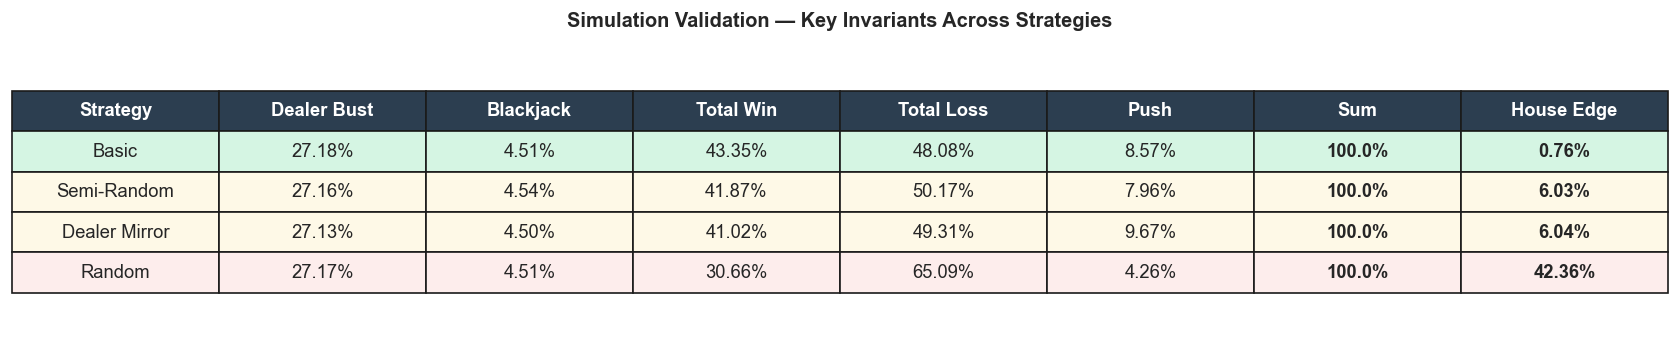

: 

In [ ]:
# Validation metrics
validation_data = []
for strategy, h in hands.items():
    dealer_bust = (h["final_dealer_value"] > 21).mean() * 100
    bj_rate = (h["outcome"] == "blackjack").mean() * 100
    total_wins = (h["outcome"].isin(["win", "blackjack"])).mean() * 100
    total_losses = (h["outcome"].isin(["lose", "bust"])).mean() * 100
    push = (h["outcome"] == "push").mean() * 100
    net = h["payout"].sum()
    house_edge = -net / (len(h) * 10) * 100

    validation_data.append([
        strategy,
        f"{dealer_bust:.2f}%",
        f"{bj_rate:.2f}%",
        f"{total_wins:.2f}%",
        f"{total_losses:.2f}%",
        f"{push:.2f}%",
        f"{total_wins + total_losses + push:.1f}%",
        f"{house_edge:.2f}%",
    ])

columns = ["Strategy", "Dealer Bust", "Blackjack", "Total Win", "Total Loss", "Push", "Sum", "House Edge"]

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis("off")

table = ax.table(
    cellText=validation_data,
    colLabels=columns,
    cellLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)

# Header style
for j in range(len(columns)):
    table[0, j].set_facecolor("#2C3E50")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Row colors
strategy_colors = {
    "Basic":         "#D5F5E3",
    "Semi-Random":   "#FEF9E7",
    "Dealer Mirror": "#FEF9E7",
    "Random":        "#FDEDEC",
}

for i, row in enumerate(validation_data):
    color = strategy_colors.get(row[0], "#FDFEFE")
    for j in range(len(columns)):
        table[i+1, j].set_facecolor(color)
        # Highlight house edge and sum columns
        if j in [6, 7]:
            table[i+1, j].set_text_props(fontweight="bold")

plt.title("Simulation Validation — Key Invariants Across Strategies",
          fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# Validation checks as clean text below
checks = [
    ("Dealer bust rate consistent across strategies (expected ~27-28%)", 
     all(abs(float(r[1].strip('%')) - 27.5) < 1.0 for r in validation_data)),
    ("Blackjack rate consistent across strategies (expected ~4.8%)", 
     all(abs(float(r[2].strip('%')) - 4.8) < 0.5 for r in validation_data)),
    ("All outcome sums = 100%", 
     all(r[6] == "100.0%" for r in validation_data)),
    ("Basic strategy house edge matches known Vegas Strip mathematics (0.5-1.5%)", 
     0.5 <= float(validation_data[0][7].strip('%')) <= 1.5),
]



**Validation checks:**
- ✓ Dealer bust rate consistent across all strategies: 27.13–27.18% (expected ~27-28%)
- ✓ Blackjack rate consistent across all strategies: 4.50–4.54% (expected ~4.8%)
- ✓ All outcome sums = 100.0%
- ✓ Basic strategy house edge 0.76% — within expected range for Vegas Strip rules (0.5–1.5%)

## Strategy Comparison: The Headlines

Four strategies, 1 million hands each. The numbers tell a clear story.

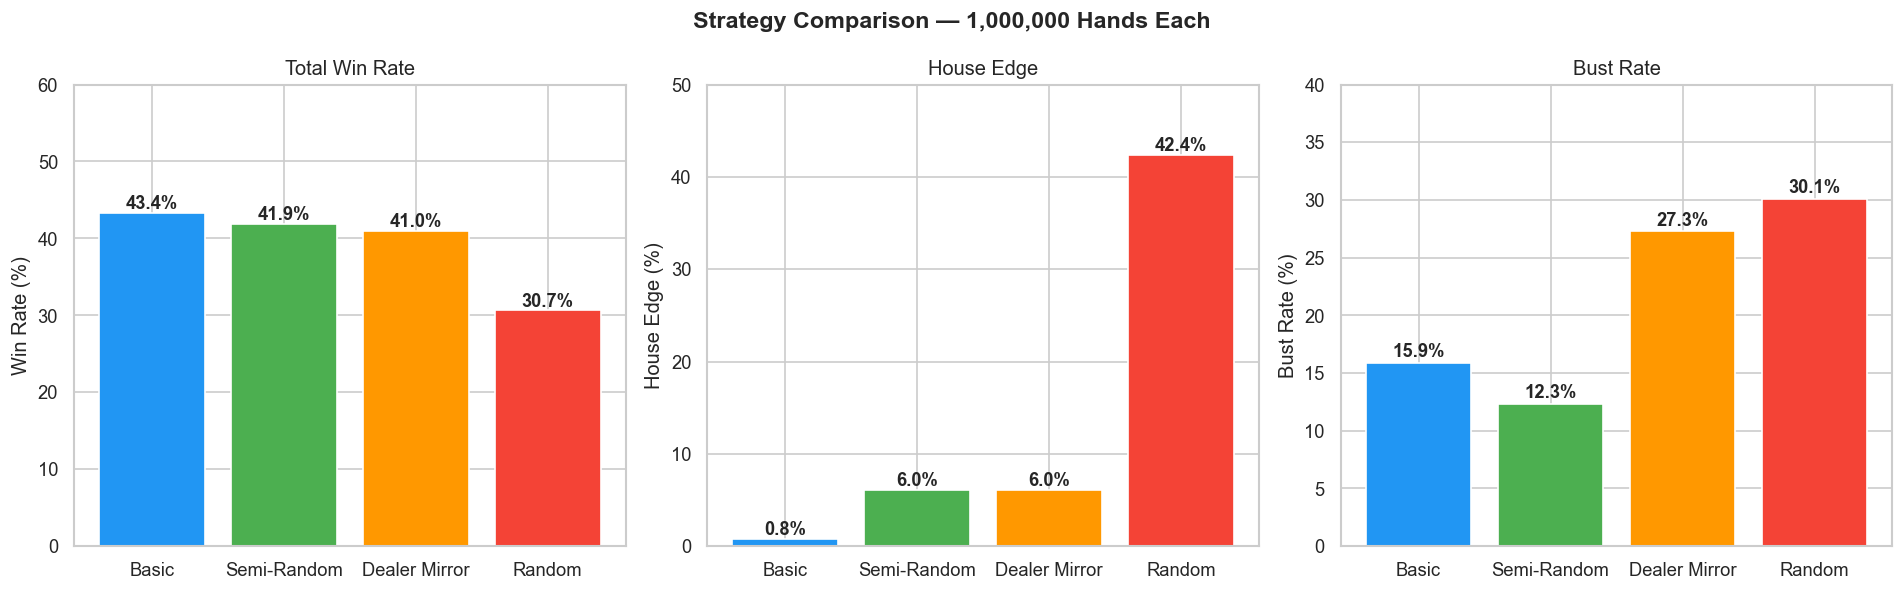

In [22]:
strategies = list(hands.keys())
colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]  # blue, green, orange, red

# Calculate key metrics
metrics = {
    "Total Win %": [],
    "Total Loss %": [],
    "Push %": [],
    "Bust %": [],
    "House Edge %": [],
}

for strategy, h in hands.items():
    metrics["Total Win %"].append((h["outcome"].isin(["win", "blackjack"])).mean() * 100)
    metrics["Total Loss %"].append((h["outcome"].isin(["lose", "bust"])).mean() * 100)
    metrics["Push %"].append((h["outcome"] == "push").mean() * 100)
    metrics["Bust %"].append((h["outcome"] == "bust").mean() * 100)
    metrics["House Edge %"].append(-h["payout"].sum() / (len(h) * 10) * 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Win rate
axes[0].bar(strategies, metrics["Total Win %"], color=colors)
axes[0].set_title("Total Win Rate")
axes[0].set_ylabel("Win Rate (%)")
axes[0].set_ylim(0, 60)
for i, v in enumerate(metrics["Total Win %"]):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

# House edge
axes[1].bar(strategies, metrics["House Edge %"], color=colors)
axes[1].set_title("House Edge")
axes[1].set_ylabel("House Edge (%)")
axes[1].set_ylim(0, 50)
for i, v in enumerate(metrics["House Edge %"]):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

# Bust rate
axes[2].bar(strategies, metrics["Bust %"], color=colors)
axes[2].set_title("Bust Rate")
axes[2].set_ylabel("Bust Rate (%)")
axes[2].set_ylim(0, 40)
for i, v in enumerate(metrics["Bust %"]):
    axes[2].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Strategy Comparison — 1,000,000 Hands Each", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Key Findings

**Basic strategy dominates** with a house edge of just 0.76% — nearly 42 percentage 
points better than random play. This is the mathematical optimum for Vegas Strip rules.

**Bust rate is the primary differentiator.** Random busts 30% of the time — nearly 
one in three hands ends before the dealer even plays. Basic strategy busts only 15.9% 
of the time. Avoiding unnecessary busts is worth more than any other single improvement 
a player can make.

**Semi-Random and Dealer Mirror perform almost identically** (house edge ~6%) despite 
very different approaches. Semi-random avoids busts more effectively (12.3% vs 27.3%) 
but loses more hands to the dealer. Dealer mirror busts frequently but wins more of the 
hands it completes. The two failure modes roughly cancel out — landing at the same 
house edge. This reveals that knowing *when* to stand on 12-16 based on dealer upcard 
is where the real value of basic strategy lies.

**Push rate tells a secondary story.** Basic strategy pushes 8.6% of the time vs 
random's 4.3%. Standing more often — even on weak hands when dealer shows a weak upcard — 
creates more ties. Pushes are not losses.

## How You Lose Matters: Bust vs. Standing Loss

Not all losses are equal. A bust means you lose before the dealer even plays. 
A standing loss means you played correctly but the dealer beat you. Understanding 
*how* each strategy loses reveals something counterintuitive about optimal play.

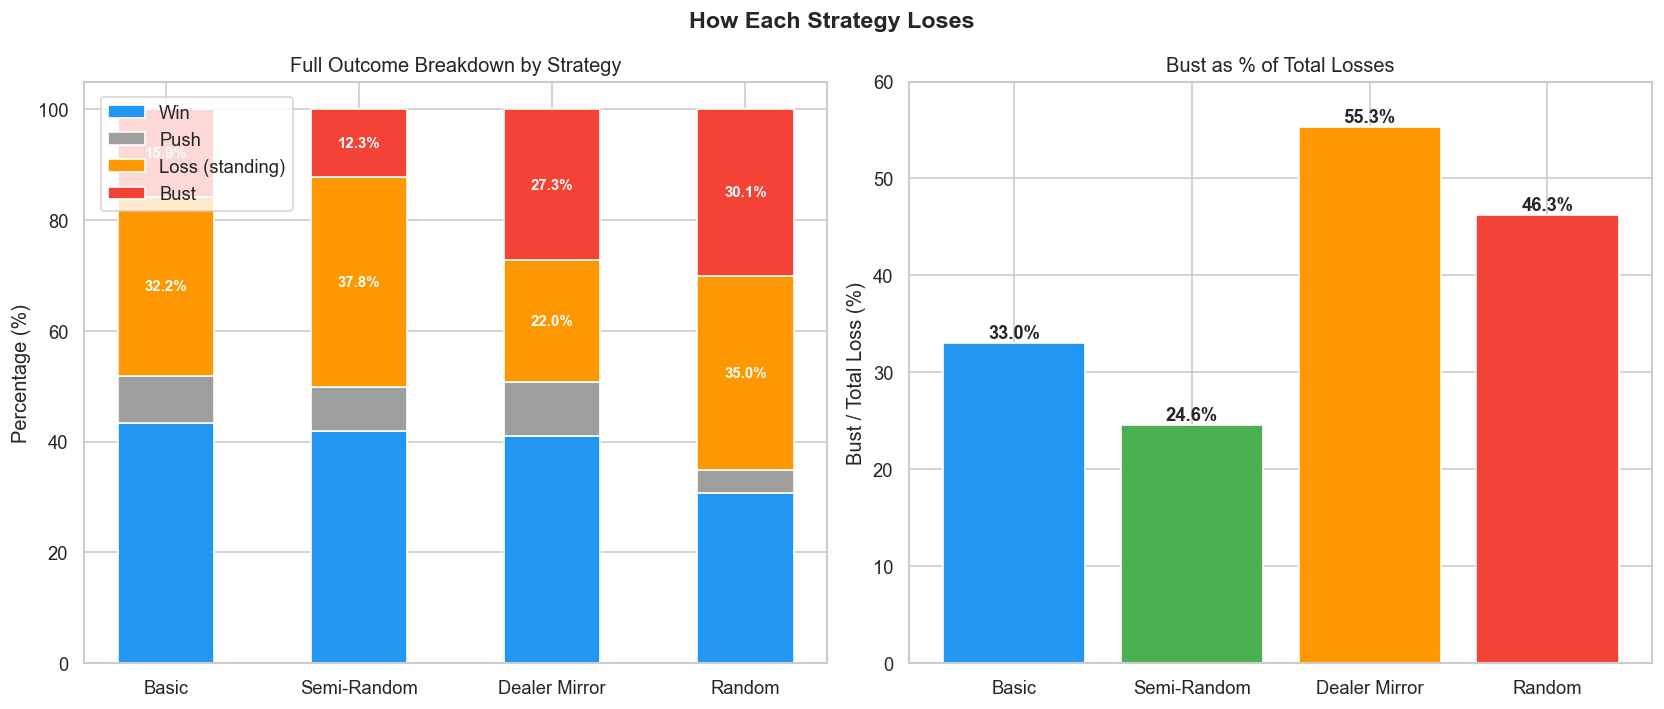

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stacked bar — loss breakdown
bust_rates = []
loss_rates = []
win_rates = []
push_rates = []

for strategy, h in hands.items():
    bust_rates.append((h["outcome"] == "bust").mean() * 100)
    loss_rates.append((h["outcome"] == "lose").mean() * 100)
    win_rates.append((h["outcome"].isin(["win", "blackjack"])).mean() * 100)
    push_rates.append((h["outcome"] == "push").mean() * 100)

x = np.arange(len(strategies))
width = 0.5

# Stacked bars
p1 = axes[0].bar(x, win_rates, width, label="Win", color="#2196F3")
p2 = axes[0].bar(x, push_rates, width, bottom=win_rates, label="Push", color="#9E9E9E")
p3 = axes[0].bar(x, loss_rates, width,
                  bottom=[w+p for w,p in zip(win_rates, push_rates)],
                  label="Loss (standing)", color="#FF9800")
p4 = axes[0].bar(x, bust_rates, width,
                  bottom=[w+p+l for w,p,l in zip(win_rates, push_rates, loss_rates)],
                  label="Bust", color="#F44336")

axes[0].set_xticks(x)
axes[0].set_xticklabels(strategies)
axes[0].set_ylabel("Percentage (%)")
axes[0].set_title("Full Outcome Breakdown by Strategy")

axes[0].legend(loc="upper left", bbox_to_anchor=(0.01, 0.99))
axes[0].set_ylim(0, 105)

# Add percentage labels on bust and loss segments
for i in range(len(strategies)):
    # Bust label
    axes[0].text(i, win_rates[i] + push_rates[i] + loss_rates[i] + bust_rates[i]/2,
                f"{bust_rates[i]:.1f}%", ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")
    # Loss label
    axes[0].text(i, win_rates[i] + push_rates[i] + loss_rates[i]/2,
                f"{loss_rates[i]:.1f}%", ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")

# Bust vs loss ratio
bust_pct_of_total_loss = [b/(b+l)*100 for b,l in zip(bust_rates, loss_rates)]

axes[1].bar(strategies, bust_pct_of_total_loss, color=colors)
axes[1].set_title("Bust as % of Total Losses")
axes[1].set_ylabel("Bust / Total Loss (%)")
axes[1].set_ylim(0, 60)
for i, v in enumerate(bust_pct_of_total_loss):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("How Each Strategy Loses", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### The Counterintuitive Finding: Lower Bust Rate ≠ Better Strategy

Semi-Random has the **lowest bust rate** of all four strategies at 12.3% — 
even lower than Basic Strategy's 15.9%. Yet its house edge (6.0%) is nearly 
8x worse than Basic (0.76%).

This directly contradicts the common intuition that "don't bust" is the 
primary goal in Blackjack. Here's why:

**Semi-Random randomly stands on hard 12-16.** About half the time it faces 
a hand value of 13 vs dealer 10, it stands. This avoids busting — but standing 
on 13 vs dealer 10 is a losing play regardless. The dealer makes 17+ most of 
the time, and 13 loses to all of them. By randomly standing, Semi-Random trades 
a bust loss for a standing loss. The outcome is the same — a loss — but the 
bust counter goes down.

**Basic Strategy accepts bust risk deliberately.** On 16 vs dealer 10, Basic 
hits — knowing it will bust roughly 62% of the time. But standing on 16 vs 
dealer 10 loses ~77% of the time anyway. Hitting is the lesser evil. Basic 
optimizes for expected value, not for avoiding busts.

**The right question is not "how do I avoid busting?" but "what is my 
expected return on each action?"** This is what separates mathematically 
optimal play from naive heuristics — and it's why 5 percentage points of 
bust rate difference translates to essentially zero house edge improvement.

Bust as a percentage of total losses tells the story clearly:
- Random: 46% of all losses are busts — hitting recklessly
- Dealer Mirror: 55% of all losses are busts — always aggressive
- Semi-Random: 25% of losses are busts — accidentally conservative
- Basic: 33% of losses are busts — deliberate, calculated risk

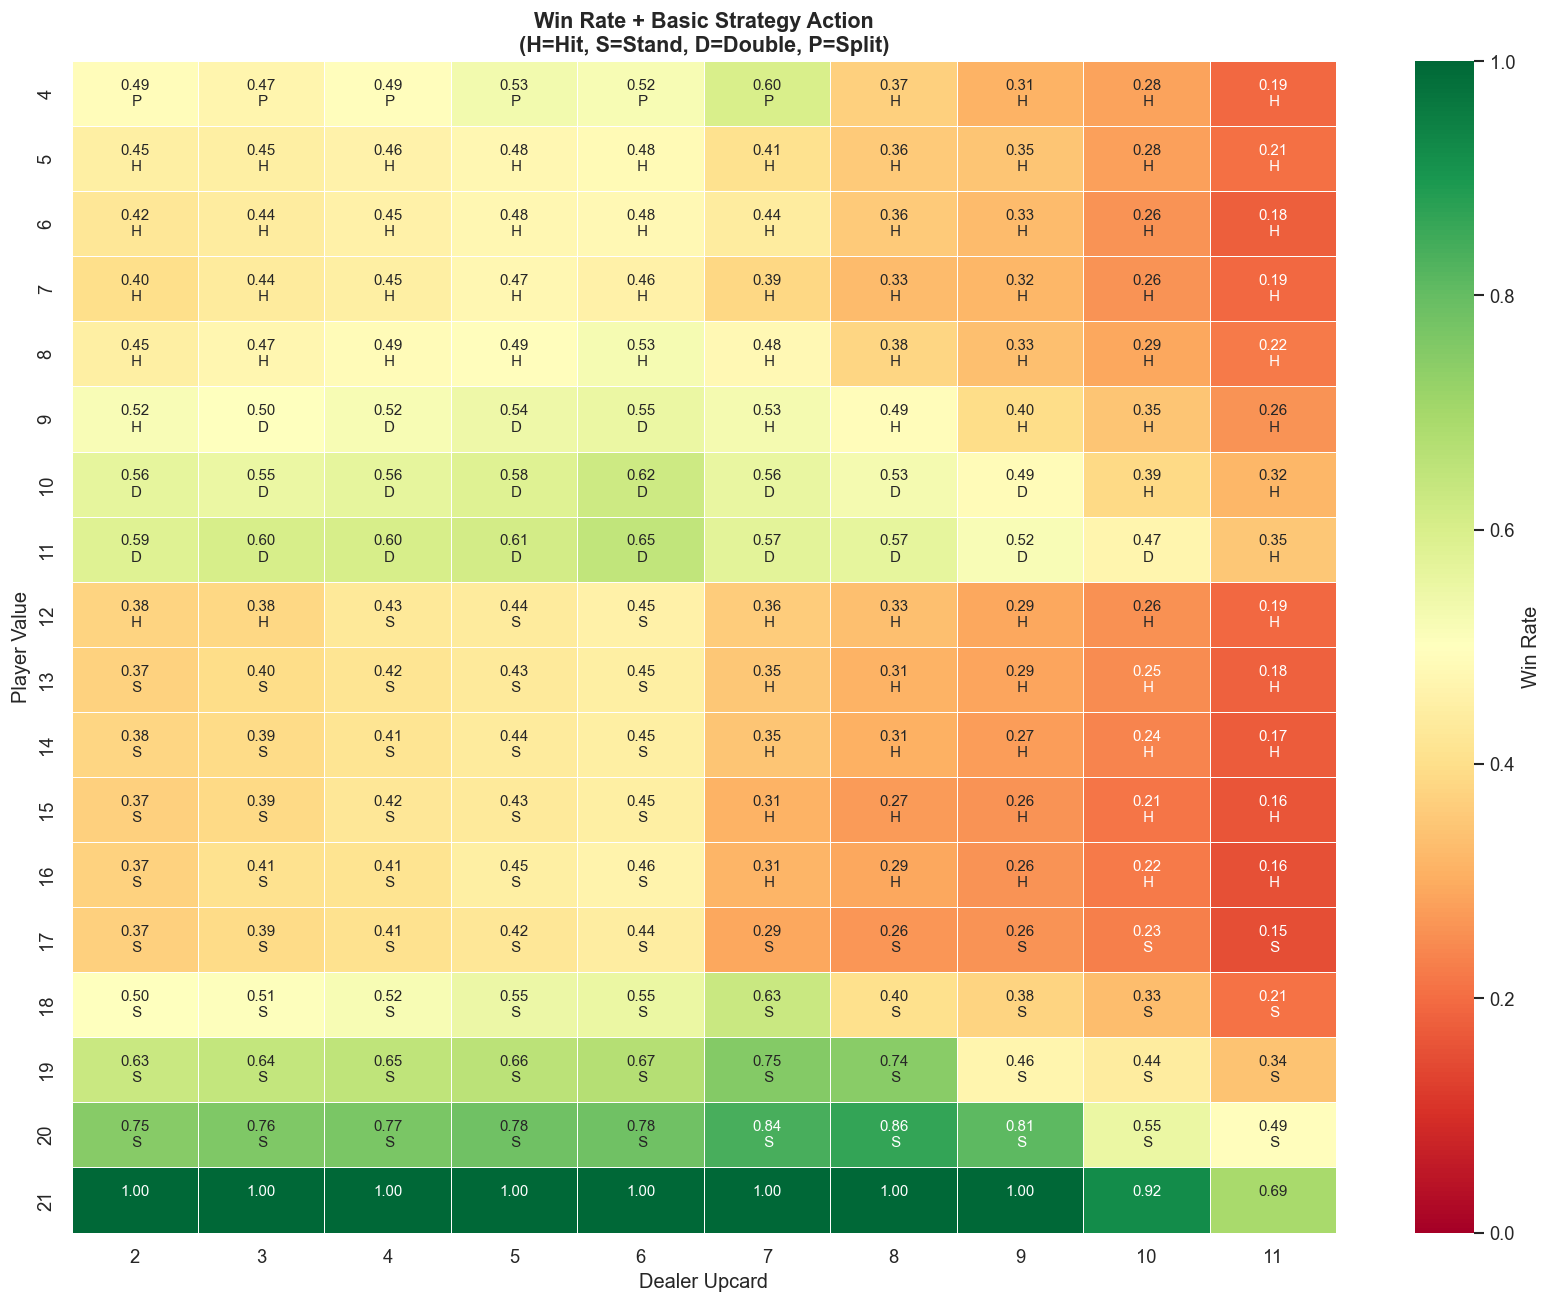

In [24]:
# Build action lookup from basic strategy decisions
# Use first decisions only — clean initial state
first_decisions = raw["Basic"][raw["Basic"]["decision_index"] == 0].copy()

# Most common action for each player_value / dealer_upcard combination
action_pivot = first_decisions.pivot_table(
    values="action",
    index="player_value",
    columns="dealer_upcard",
    aggfunc=lambda x: x.mode()[0]  # most frequent action
)

# Win rate pivot — same index/columns
win_pivot = first_decisions.pivot_table(
    values="is_win",
    index="player_value",
    columns="dealer_upcard",
    aggfunc="mean"
)

# Action color map
action_colors = {
    "hit":      "H",
    "stand":    "S",
    "double":   "D",
    "split":    "P",
    "none":     " ",
}

# Build annotation array — win rate + action
annot = pd.DataFrame(index=win_pivot.index, columns=win_pivot.columns)
for idx in win_pivot.index:
    for col in win_pivot.columns:
        wr = win_pivot.loc[idx, col]
        if pd.isna(wr):
            annot.loc[idx, col] = ""
            continue
        action = action_pivot.loc[idx, col] if idx in action_pivot.index and col in action_pivot.columns else ""
        action_code = action_colors.get(action, "")
        annot.loc[idx, col] = f"{wr:.2f}\n {action_code}"

plt.figure(figsize=(14, 11))
sns.heatmap(
    win_pivot,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Win Rate"},
    annot_kws={"size": 9}
)
plt.title("Win Rate + Basic Strategy Action\n(H=Hit, S=Stand, D=Double, P=Split)",
          fontsize=13, fontweight="bold")
plt.xlabel("Dealer Upcard", fontsize=12)
plt.ylabel("Player Value", fontsize=12)
plt.tight_layout()
plt.show()

## Decision Analysis: Where Strategy Actually Matters

The headline numbers show *that* basic strategy is better. 
The heatmaps show *why* — and *where* the difference is made.

### Reading the Win Rate Heatmap

This is the objective difficulty of each game state — independent of what 
decision the player makes next. Green = favorable, Red = unfavorable.

**Clear patterns emerge:**

- **Dealer 2-6 (weak upcards)** — the entire column is noticeably greener. 
  The dealer is likely to bust, making even weak player hands competitive.
  
- **Dealer 10-11 (strong upcards)** — the columns shift red. The dealer 
  completes strong hands frequently, putting pressure on the player.

- **Player value 17-20** — green across all dealer upcards. Strong hands 
  win regardless of dealer showing.

- **Player value 12-16 vs dealer 7+** — the danger zone. Red across the 
  board. These are the hands where strategy matters most — there is no 
  good option, only a least-bad one.

The heatmap explains *why* basic strategy makes the decisions it does. 
Next — what does it actually decide?

### Win Rate + Action: The Strategy Card Explained

Each cell shows win rate (top) and basic strategy action (bottom).
**H**=Hit, **S**=Stand, **D**=Double, **P**=Split.

**The pattern is clear once you see it:**

- **Double (D) appears in green/yellow cells** — basic strategy doubles exactly 
  when the situation is already favorable. Hand value 9-11 vs weak dealer upcards. 
  Doubling here extracts maximum value from a winning position.

- **Stand (S) on 12-16 vs dealer 2-6** — these cells are orange/red, meaning 
  standing here still loses more than half the time. But the dealer is likely to 
  bust, so standing gives the dealer a chance to self-destruct. Hitting risks 
  busting before that happens.

- **Hit (H) on 12-16 vs dealer 7+** — also red cells, but now standing is even 
  worse. Dealer 7+ completes strong hands frequently. The player must take the 
  bust risk because the alternative is almost certain loss.

- **The most important insight:** basic strategy doesn't try to win every hand. 
  It minimizes losses in bad situations and maximizes gains in good ones. 
  Most of the board is red — the game is structurally unfavorable. 
  Basic strategy is about damage control and opportunism, not optimism.

**A note on card counting:** this heatmap assumes a neutral deck composition. 
Card counting shifts this picture — when the shoe is rich in high cards, 
dealer bust probability increases, turning some of those red 12-16 cells 
slightly greener. Combined with increased bet sizing, this is how counting 
creates a player edge. We explore this in the session analysis notebook.

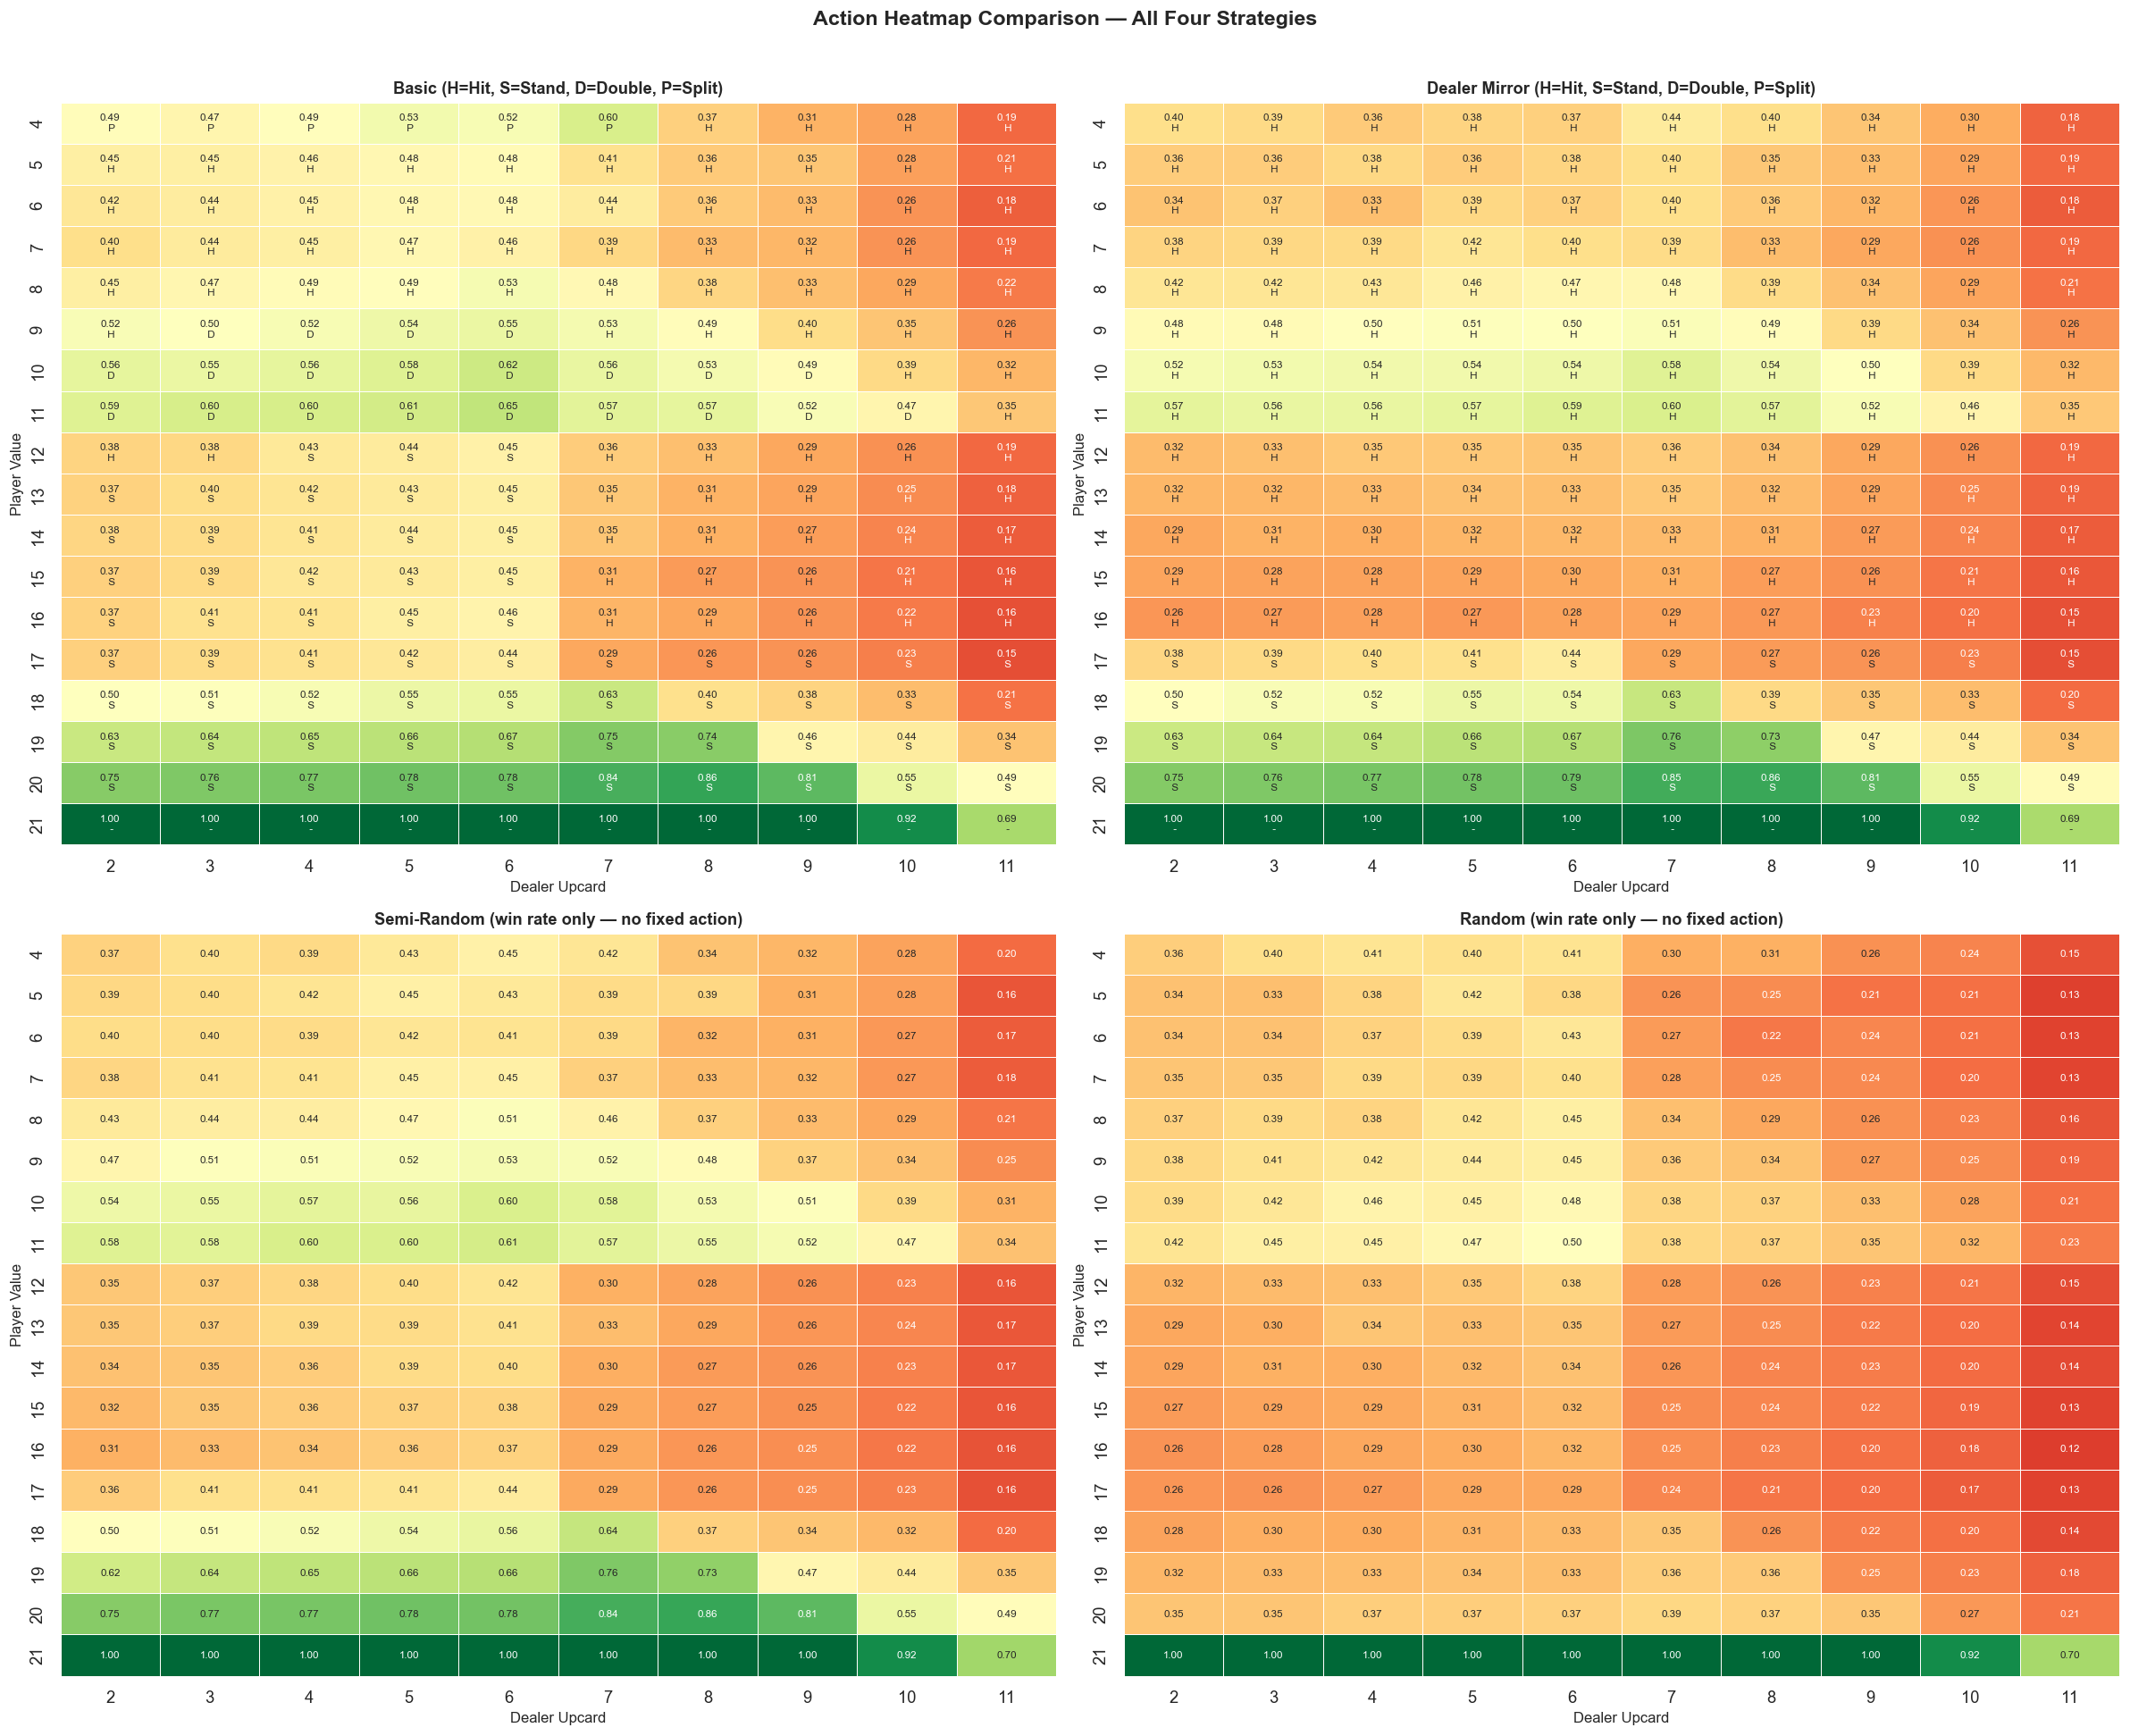

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes_flat = axes.flatten()

strategy_order = ["Basic", "Dealer Mirror", "Semi-Random", "Random"]
deterministic = {"Basic", "Dealer Mirror"}  # only these get action annotations

action_display = {
    "hit": "H", "stand": "S", "double": "D",
    "split": "P", "surrender": "R", "none": "-"
}

for ax, strategy in zip(axes_flat, strategy_order):
    first_dec = raw[strategy][raw[strategy]["decision_index"] == 0].copy()

    win_piv = first_dec.pivot_table(
        values="is_win",
        index="player_value",
        columns="dealer_upcard",
        aggfunc="mean"
    )

    if strategy in deterministic:
        action_piv = first_dec.pivot_table(
            values="action",
            index="player_value",
            columns="dealer_upcard",
            aggfunc=lambda x: x.mode()[0]
        )

        common_idx = win_piv.index.intersection(action_piv.index)
        common_col = win_piv.columns.intersection(action_piv.columns)
        win_piv = win_piv.loc[common_idx, common_col]
        action_piv = action_piv.loc[common_idx, common_col]

        annot = pd.DataFrame(index=win_piv.index, columns=win_piv.columns)
        for idx in win_piv.index:
            for col in win_piv.columns:
                wr = win_piv.loc[idx, col]
                if pd.isna(wr):
                    annot.loc[idx, col] = ""
                    continue
                action = action_piv.loc[idx, col] if idx in action_piv.index and col in action_piv.columns else ""
                code = action_display.get(action, "")
                annot.loc[idx, col] = f"{wr:.2f}\n {code}"

        sns.heatmap(
            win_piv,
            annot=annot,
            fmt="",
            cmap="RdYlGn",
            vmin=0, vmax=1,
            linewidths=0.3,
            ax=ax,
            cbar=False,
            annot_kws={"size": 7}
        )
    else:
        # Win rate only — no action annotations
        sns.heatmap(
            win_piv,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            vmin=0, vmax=1,
            linewidths=0.3,
            ax=ax,
            cbar=False,
            annot_kws={"size": 7}
        )

    ax.set_title(
        f"{strategy}" + (" (H=Hit, S=Stand, D=Double, P=Split)" if strategy in deterministic else " (win rate only — no fixed action)"),
        fontsize=11, fontweight="bold"
    )
    ax.set_xlabel("Dealer Upcard", fontsize=10)
    ax.set_ylabel("Player Value", fontsize=10)

plt.suptitle("Action Heatmap Comparison — All Four Strategies",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### What the Comparison Reveals

The four heatmaps share identical win rate color patterns — the underlying 
game difficulty is the same regardless of strategy. What differs is what 
each strategy *does* in each situation.

**Basic Strategy** shows deliberate structure throughout:
- **D (Double)** concentrated on rows 9-11 vs weak dealer upcards — 
  extracting maximum value from favorable positions
- **P (Split)** on pairs vs weak dealer — creating two winning hands 
  from one
- **S (Stand)** on 12-16 vs dealer 2-6 — patience when dealer is likely 
  to bust
- **H (Hit)** on 12-16 vs dealer 7+ — accepting bust risk because 
  standing is worse

**Dealer Mirror** shows a clean horizontal cut at 17 — hit everything 
below, stand above, regardless of context. The pattern is simple and 
consistent. But it never doubles, never splits, and stands on 12-16 
vs dealer 7+ where hitting is correct. It leaves money on the table 
in good situations and plays incorrectly in bad ones.

**Semi-Random and Random** show no action structure — only win rates. 
There is no fixed decision at any game state. The color gradient is 
identical to the other two strategies, confirming that win rate is a 
property of the game state, not the strategy. What strategy controls 
is whether you *capture* that win rate through correct play.

**The critical region: rows 12-16, dealer upcards 2-6** (middle-left zone).
This is where Basic stands and Dealer Mirror hits. The win rates here 
are 37-45% — orange/yellow, not favorable but not hopeless. Basic stands, 
gives the dealer a chance to bust (~35% probability with a weak upcard), 
and captures those wins. Dealer Mirror hits, risks busting before the 
dealer gets the chance. This single region accounts for a large portion 
of the house edge gap between the two strategies.

**Doubling and splitting** — visible only in Basic — are the other major 
source of edge. These actions appear in the yellow-green cells where the 
player already has an advantage. Multiplying the bet in a favorable 
situation is how Basic extracts extra value that Dealer Mirror and 
Semi-Random completely miss.

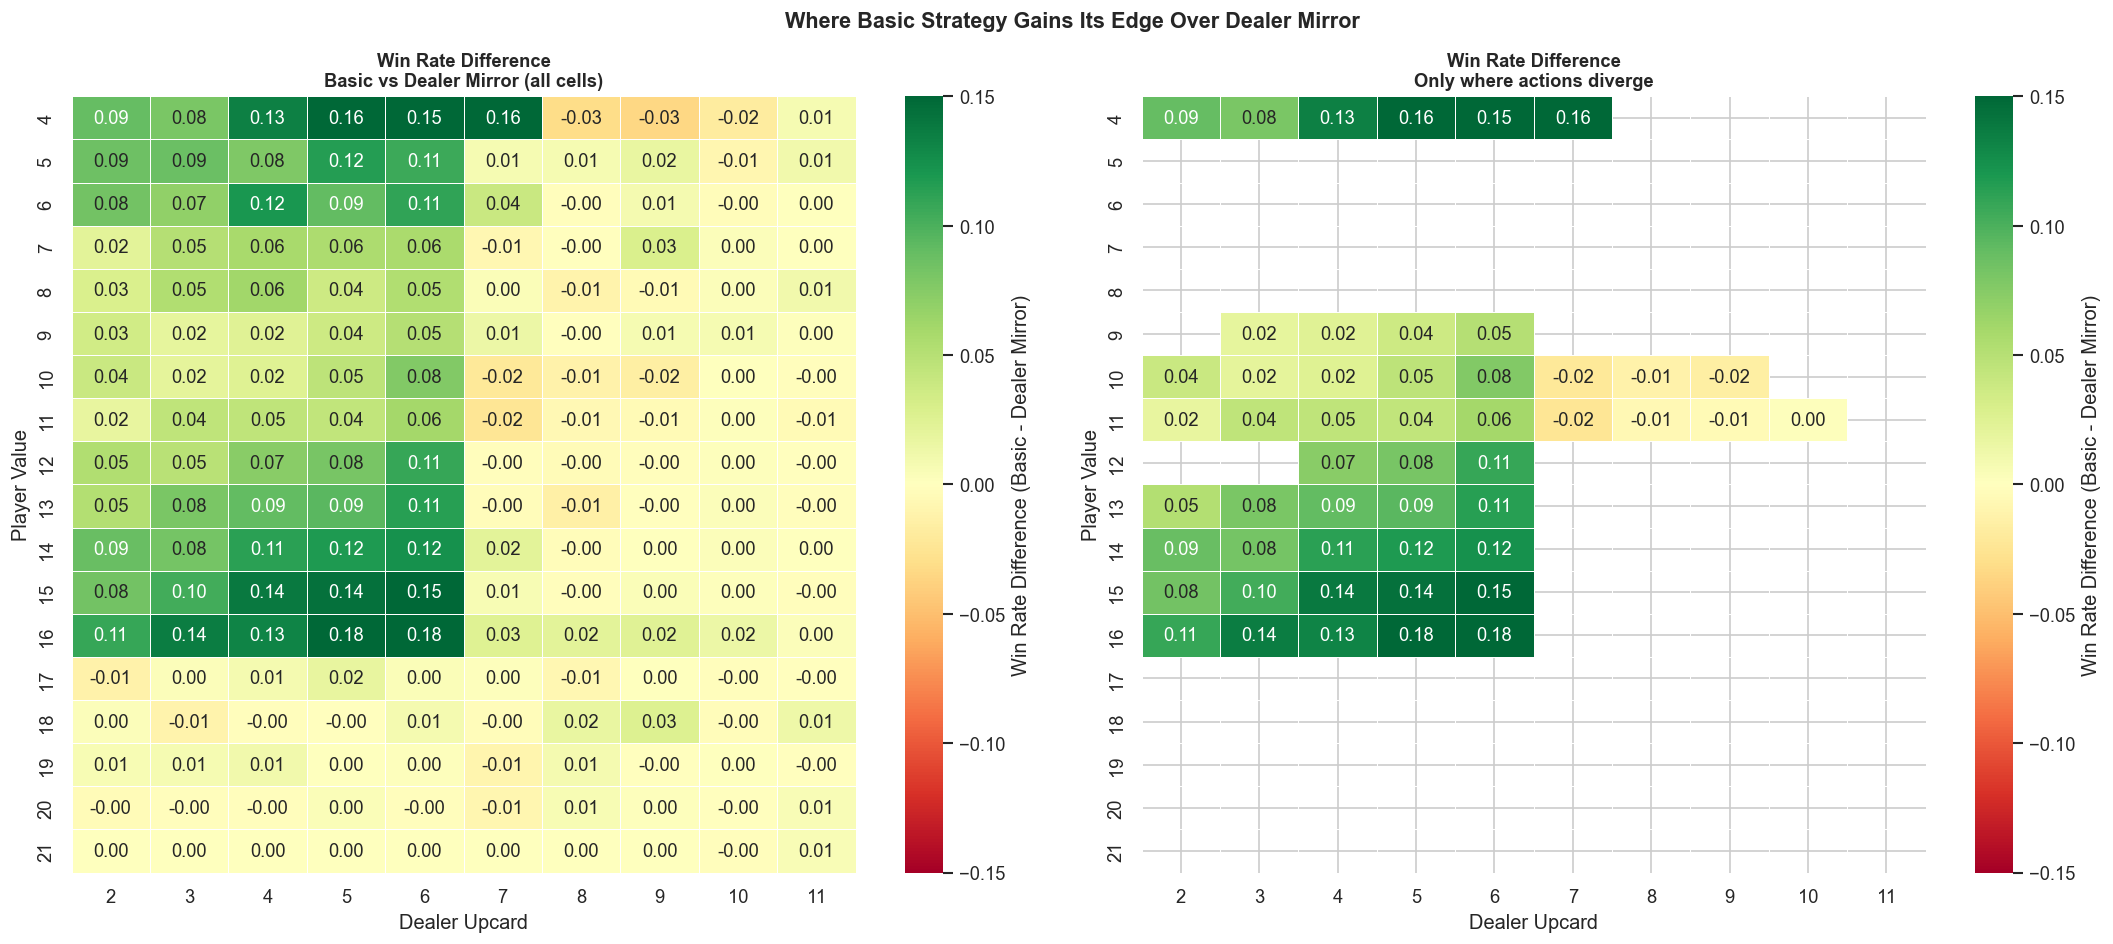

In [26]:
# Quantify win rate difference where strategies diverge from basic

basic_first = raw["Basic"][raw["Basic"]["decision_index"] == 0].copy()
mirror_first = raw["Dealer Mirror"][raw["Dealer Mirror"]["decision_index"] == 0].copy()

# Win rate pivots
basic_win = basic_first.pivot_table(
    values="is_win", index="player_value",
    columns="dealer_upcard", aggfunc="mean"
)
mirror_win = mirror_first.pivot_table(
    values="is_win", index="player_value",
    columns="dealer_upcard", aggfunc="mean"
)

# Action pivots
basic_action = basic_first.pivot_table(
    values="action", index="player_value",
    columns="dealer_upcard", aggfunc=lambda x: x.mode()[0]
)
mirror_action = mirror_first.pivot_table(
    values="action", index="player_value",
    columns="dealer_upcard", aggfunc=lambda x: x.mode()[0]
)

# Align
common_idx = basic_win.index.intersection(mirror_win.index)
common_col = basic_win.columns.intersection(mirror_win.columns)
basic_win = basic_win.loc[common_idx, common_col]
mirror_win = mirror_win.loc[common_idx, common_col]
basic_action = basic_action.loc[
    basic_action.index.intersection(common_idx),
    basic_action.columns.intersection(common_col)
]
mirror_action = mirror_action.loc[
    mirror_action.index.intersection(common_idx),
    mirror_action.columns.intersection(common_col)
]

# Win rate difference — positive means basic does better
win_diff = basic_win - mirror_win

# Mask cells where actions are the same — only show divergence
action_diff_mask = pd.DataFrame(True, index=common_idx, columns=common_col)
for idx in common_idx:
    for col in common_col:
        if idx in basic_action.index and col in basic_action.columns and \
           idx in mirror_action.index and col in mirror_action.columns:
            if basic_action.loc[idx, col] == mirror_action.loc[idx, col]:
                action_diff_mask.loc[idx, col] = False

# Apply mask — NaN where actions are same
win_diff_masked = win_diff.where(action_diff_mask)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left — full win rate difference
sns.heatmap(
    win_diff,
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    vmin=-0.15, vmax=0.15,
    linewidths=0.3,
    ax=axes[0],
    cbar_kws={"label": "Win Rate Difference (Basic - Dealer Mirror)"}
)
axes[0].set_title("Win Rate Difference\nBasic vs Dealer Mirror (all cells)",
                   fontsize=11, fontweight="bold")
axes[0].set_xlabel("Dealer Upcard")
axes[0].set_ylabel("Player Value")

# Right — only where actions diverge
sns.heatmap(
    win_diff_masked,
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    vmin=-0.15, vmax=0.15,
    linewidths=0.3,
    ax=axes[1],
    cbar_kws={"label": "Win Rate Difference (Basic - Dealer Mirror)"}
)
axes[1].set_title("Win Rate Difference\nOnly where actions diverge",
                   fontsize=11, fontweight="bold")
axes[1].set_xlabel("Dealer Upcard")
axes[1].set_ylabel("Player Value")

plt.suptitle("Where Basic Strategy Gains Its Edge Over Dealer Mirror",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Quantifying the Edge: Where Basic Outperforms Dealer Mirror

The left heatmap shows win rate difference across all game states — 
green means basic wins more, red means dealer mirror wins more.

The right heatmap isolates only the cells where the two strategies 
make **different decisions** — this is where the edge actually comes from.

**Key observations:**

- **Rows 9-11 (doubling zone)** — Basic doubles, Dealer Mirror hits. 
  The win rate difference here is positive — Basic captures more value 
  by doubling the bet in favorable situations.

- **Rows 12-16 vs dealer 2-6** — Basic stands, Dealer Mirror hits. 
  Strong green — Basic wins significantly more here by letting the 
  dealer bust rather than risking its own bust.

- **Pairs (rows 4, 6, 8, etc.) vs weak dealer** — Basic splits, 
  Dealer Mirror hits. Splitting creates two hands in favorable 
  situations, doubling the opportunity.

The cells that are grey (no difference shown) are states where both 
strategies make the same decision — the edge comes entirely from the 
divergent cells. This visualization proves that basic strategy's 
advantage is concentrated in specific, identifiable situations — 
not spread randomly across the board.

## Conclusions

### What This Analysis Demonstrates

**1. Strategy matters enormously — but not uniformly.**
Basic strategy reduces house edge from 42.4% (random) to 0.76% — a 41.6 
percentage point improvement. But this gain is not spread evenly across 
all hands. It comes from specific, identifiable decision points that naive 
strategies consistently get wrong.

**2. Avoiding busts is not the goal. Expected value is.**
Semi-Random achieves the lowest bust rate (12.3%) of all four strategies — 
lower even than Basic (15.9%). Yet its house edge is 6.0% vs Basic's 0.76%. 
Randomly standing on 12-16 avoids busts but trades them for standing losses. 
Basic strategy accepts calculated bust risk because the alternative is worse. 
This is the single most counterintuitive finding in the analysis.

**3. The danger zone is 12-16 vs dealer 2-6.**
This region accounts for the largest win rate differences between Basic and 
naive strategies. Standing here — even with a weak hand — lets a likely-busting 
dealer self-destruct. Hitting risks busting before that happens. Basic stands. 
Dealer Mirror hits. The difference is up to 18 percentage points per hand.

**4. Doubling and splitting are the player's weapons.**
These actions appear only in favorable situations — yellow/green cells where 
the player already has an edge. Basic strategy doubles the bet exactly when 
it should. Dealer Mirror and Semi-Random never double or split, leaving 
significant value uncaptured in the hands they do win.

**5. The game is structurally unfavorable — strategy is damage control.**
Most of the win rate heatmap is red and orange. The player acts first, 
meaning busts happen before the dealer plays. No strategy overcomes this 
structural disadvantage entirely. Basic strategy minimizes it. Card counting 
can shift specific cells from unfavorable to neutral — explored in the 
session analysis notebook.

---

### What This Project Demonstrates

This analysis was built on a Monte Carlo simulator written from scratch with:
- A pluggable strategy interface — any decision logic implementable in one method
- Configurable casino rules — deck count, payout ratios, dealer behavior
- Per-decision data recording — every decision captured with full game context
- Validated output — house edge, dealer bust rate, and blackjack frequency 
  all match known Blackjack mathematics

The simulator is reusable. In Phase 3, a neural network will be trained on 
this same decision data to learn optimal strategy from scratch — without being 
told the rules. In Phase 4, a reinforcement learning agent will use the 
simulator as its environment, learning through play rather than supervised data.



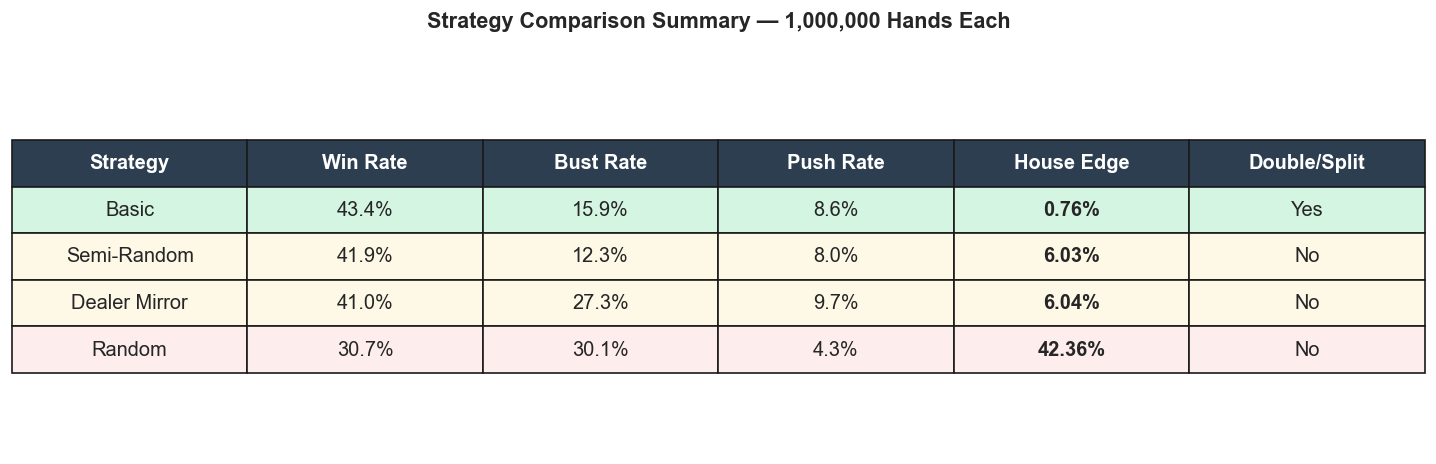

In [27]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

summary_data = []
for strategy, h in hands.items():
    net = h["payout"].sum()
    wagered = len(h) * 10
    summary_data.append([
        strategy,
        f"{(h['outcome'].isin(['win','blackjack'])).mean()*100:.1f}%",
        f"{(h['outcome']=='bust').mean()*100:.1f}%",
        f"{(h['outcome']=='push').mean()*100:.1f}%",
        f"{-net/wagered*100:.2f}%",
        "Yes" if strategy == "Basic" else "No",
    ])

columns = ["Strategy", "Win Rate", "Bust Rate", "Push Rate", "House Edge", "Double/Split"]
table = ax.table(
    cellText=summary_data,
    colLabels=columns,
    cellLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.2)

# Style header
for j in range(len(columns)):
    table[0, j].set_facecolor("#2C3E50")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Style rows
strategy_colors = {
    "Basic":         "#D5F5E3",
    "Semi-Random":   "#FEF9E7",
    "Dealer Mirror": "#FEF9E7",
    "Random":        "#FDEDEC",
}

for i, (row, _) in enumerate(zip(summary_data, hands.items())):
    strategy = row[0]
    color = strategy_colors.get(strategy, "#FDFEFE")
    for j in range(len(columns)):
        table[i+1, j].set_facecolor(color)
        # Highlight house edge column
        if j == 4:
            table[i+1, j].set_text_props(fontweight="bold")

plt.title("Strategy Comparison Summary — 1,000,000 Hands Each",
          fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()